In [18]:
# Imports
import os
import sys
from IPython.display import display

from py_scripts.parser_registry import parse_files, list_parsers

# Backend selection ('music21' | 'partitura')
PARSING_BACKEND = 'partitura'

# Configuration
FILTER_ZERO_DURATION = True # filter out notes with duration 0 (grace notes)
ADJUST_FRACTIONAL_DURATION = True # rounds Duration, Local Onset, and Global Onset to 3 decimals
PARSE_ENHARMONIC = True     # add 'Pitch Enharmonic' column grounded in source notation
PLOTTING_BACKEND = 'bokeh'  # 'plt' | 'bokeh' | 'none'

SHOW_MEASURE_LINES = True   # draw vertical measure lines at measure starts
MEASURE_LINE_COLOR = 'black'  # color for the measure lines

HOVER_ENABLED = True        # enable hover tool (Bokeh only)
HOVER_FIELDS = ['measure', 'local_onset', 'global_onset', 'duration', 'pitch', 'pitch_enharmonic', 'midi', 'voice', 'xml_id'] # hover options as list

DISPLAY_PREVIEW = True      # show a preview of the parsed data as df
PREVIEW_ROWS = 20          # number of rows to show in the preview

CLEANUP_REMOTE = True       # if source is a URL, delete temp file after parsing
RETURN_PLOTS = False        # include plot objects in results under 'plot'
STRIP_TIES = True           # merge tied notes into single notes (music21 backend only)
ALIGN_ACCIDENT_SCHEMA = True # align accidentals on both parsing backends to the same schema (Pitch Enharmonic is parsed only in b/# format)

COLORIZE_VOICES = True      # color-code notes by voice/part in the piano roll
PALETTE = 'Category20'      # palette name ('Category10'/'tab10', 'Category20'/'tab20', 'Set3', or a list)
INCLUDE_XML_IDS = True      # if MEI, include xml:id per note as 'xml_id' column

# List of file sources (URLs or local paths)
FILE_SOURCES = [
    'https://analyse.hfm-weimar.de/database/02/PrJode_Jos0302_COM_1-5_MissaDapac_002_00006.xml',
    # 'https://raw.githubusercontent.com/humdrum-tools/bach-wtc-fugues/refs/heads/master/kern/wtc1f04.krn',
    #'https://raw.githubusercontent.com/humdrum-tools/bach-wtc/refs/heads/main/kern/wtc1f22.krn',
    # 'https://raw.githubusercontent.com/trompamusic-encodings/Beethoven_Op31_No3_HenleUrtext/refs/heads/master/Beethoven_Op31_No3_3-HenleUrtext.mei'
    'https://raw.githubusercontent.com/piasteuck/winterreise-analysis/refs/heads/main/Schubert_Winterreise_Dataset_v2-0/01_RawData/score_musicxml/Schubert_D911-20.xml',
    # 'https://raw.githubusercontent.com/music-encoding/sample-encodings/main/MEI_5.0/Music/Complete_examples/Bach-JS_Ein_feste_Burg.mei',
    # 'https://raw.githubusercontent.com/music-encoding/sample-encodings/main/MEI_3.0/Music/Complete_examples/Mozart_Fuge_G_minor.mei'
    # 'https://raw.githubusercontent.com/humdrum-tools/bach-wtc/refs/heads/main/kern/wtc2f05.krn',
    # 'C:/Users/egorp/OneDrive/Desktop/weimar_ftp_backup/dokuwiki/database/05/CaSe_11_UNSP_UNSP_Danksagenw_005_00011.xml'  # If you prefer backslashes, make it a raw string: r'C:\Users\egorp\...'
]

# Plot sizing
PLOT_SIZE_X = 900  # width in pixels
PLOT_SIZE_Y = 600   # height in pixels

# Zoom tool dimensions: 'both' | 'width' (x-only) | 'height' (y-only)
# Bokeh only!
ZOOM_DRAG_DIM = 'both'
ZOOM_WHEEL_DIM = 'width'

# Parse and visualize
results, dfs_by_name, df_processed = parse_files(
    FILE_SOURCES,
    parsing_backend=PARSING_BACKEND,
    filter_zero_duration=FILTER_ZERO_DURATION,
    adjust_fractional_duration=ADJUST_FRACTIONAL_DURATION,
    parse_enharmonic=PARSE_ENHARMONIC,
    backend=PLOTTING_BACKEND,
    show_measure_lines=SHOW_MEASURE_LINES,
    measure_line_color=MEASURE_LINE_COLOR,
    show_hover=HOVER_ENABLED,
    hover_fields=HOVER_FIELDS,
    display_preview=DISPLAY_PREVIEW,
    preview_rows=PREVIEW_ROWS,
    cleanup_remote=CLEANUP_REMOTE,
    return_plots=RETURN_PLOTS,
    plot_width=PLOT_SIZE_X,
    plot_height=PLOT_SIZE_Y,
    zoom_drag_dim=ZOOM_DRAG_DIM,
    zoom_wheel_dim=ZOOM_WHEEL_DIM,
    strip_ties=STRIP_TIES,
    align_accident_schema=ALIGN_ACCIDENT_SCHEMA,
    colorize_voices=COLORIZE_VOICES,
    palette=PALETTE,
    include_xml_ids=INCLUDE_XML_IDS
)

# Show quick summary
print('Parsed DataFrames:')
for item in results:
    name = item['name']
    df = item['df']
    pos_dur = df.loc[df['Duration'] > 0, 'Duration'] if 'Duration' in df.columns else None
    min_dur_str = str(float(pos_dur.min())) if pos_dur is not None and len(pos_dur) > 0 else 'n/a'
    voice_count = df['Voice'].nunique() if 'Voice' in df.columns else 0
    voice_names = sorted(df['Voice'].unique().tolist()) if 'Voice' in df.columns else []
    print(f"- {name}: rows={len(df)}, unique_pitches={df['MIDI'].nunique()}, min_duration={min_dur_str}, voices={voice_count} ({voice_names})")


Processing (partitura): PrJode_Jos0302_COM_1-5_MissaDapac_002_00006.xml -> 00_prjode_jos0302_com_1_5_missadapac_002_00006


,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice,xml_id
0,1,0.0,0.0,8.0,G3,G3,55,Voice - Voice 1,<NA>
1,1,8.0,8.0,4.0,F3,F3,53,Voice - Voice 1,<NA>
2,1,12.0,12.0,3.0,G3,G3,55,Voice - Voice 1,<NA>
3,1,12.0,12.0,8.0,G4,G4,67,Voice - Voice 1,<NA>
4,1,15.0,15.0,1.0,A3,A3,57,Voice - Voice 1,<NA>
5,1,16.0,16.0,2.0,A#3,Bb3,58,Voice - Voice 1,<NA>
6,1,18.0,18.0,2.0,G3,G3,55,Voice - Voice 1,<NA>
7,1,20.0,20.0,4.0,A3,A3,57,Voice - Voice 1,<NA>
8,1,20.0,20.0,4.0,F4,F4,65,Voice - Voice 1,<NA>
9,1,24.0,24.0,1.0,G3,G3,55,Voice - Voice 1,<NA>


Rows: 755, unique pitches: 24
Processing (partitura): Schubert_D911-20.xml -> 01_schubert_d911_20


c:\Users\sende\miniconda3\envs\camat_v2\Lib\site-packages\partitura\directions.py:514: UserWarning: error parsing "Mäßig" (UnexpectedCharacters)
  warnings.warn('error parsing "{}" ({})'.format(string, type(e).__name__))
c:\Users\sende\miniconda3\envs\camat_v2\Lib\site-packages\partitura\io\importmusicxml.py:1065: UserWarning: ignoring direction type: other-direction {'default-y': '14', 'print-object': 'no'}
  warnings.warn("ignoring direction type: {} {}".format(dt.tag, dt.attrib))
c:\Users\sende\miniconda3\envs\camat_v2\Lib\site-packages\partitura\io\importmusicxml.py:1065: UserWarning: ignoring direction type: other-direction {'default-y': '-53', 'print-object': 'no'}
  warnings.warn("ignoring direction type: {} {}".format(dt.tag, dt.attrib))


,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice,xml_id
0,1,1.50,-0.50,0.25,A#3,G4,58,Piano - Voice 4,<NA>
1,1,1.50,-0.50,0.25,G4,Bb3,67,Piano - Voice 1,<NA>
2,1,1.75,-0.25,0.25,C4,A4,60,Piano - Voice 4,<NA>
3,1,1.75,-0.25,0.25,A4,C4,69,Piano - Voice 1,<NA>
4,1,0.00,0.00,0.50,G3,G4,55,Piano - Voice 4,<NA>
5,1,0.00,0.00,0.50,D4,Bb4,62,Piano - Voice 1,<NA>
6,1,0.00,0.00,0.50,G4,G3,67,Piano - Voice 1,<NA>
7,1,0.00,0.00,0.50,A#4,D4,70,Piano - Voice 1,<NA>
8,1,0.50,0.50,0.50,G3,G4,55,Piano - Voice 4,<NA>
9,1,0.50,0.50,0.50,D4,Bb4,62,Piano - Voice 1,<NA>


Rows: 1131, unique pitches: 43
Parsed DataFrames:
- 00_prjode_jos0302_com_1_5_missadapac_002_00006: rows=755, unique_pitches=24, min_duration=0.5, voices=1 (['Voice - Voice 1'])
- 01_schubert_d911_20: rows=1131, unique_pitches=43, min_duration=0.125, voices=6 (['Piano - Voice 1', 'Piano - Voice 2', 'Piano - Voice 3', 'Piano - Voice 4', 'Piano - Voice 5', 'Voice - Voice 1'])


In [30]:
list(dfs_by_name)


['00_prjode_jos0302_com_1_5_missadapac_002_00006', '01_schubert_d911_20']

In [31]:
list(FILE_SOURCES)

['https://analyse.hfm-weimar.de/database/02/PrJode_Jos0302_COM_1-5_MissaDapac_002_00006.xml',
 'https://raw.githubusercontent.com/piasteuck/winterreise-analysis/refs/heads/main/Schubert_Winterreise_Dataset_v2-0/01_RawData/score_musicxml/Schubert_D911-20.xml']

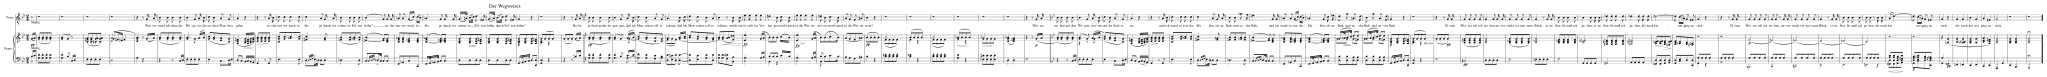

In [32]:
from py_scripts import (
    vrv_set_options, vrv_load_from_url, vrv_render_all_pages, vrv_display_svg
)

url = FILE_SOURCES[1]

vrv_set_options(pageWidth=12000, pageHeight=1200, scale=40, breaks="none")
_ = vrv_load_from_url(url)  # auto detects 'mei' | 'musicxml' | 'humdrum'
for svg in vrv_render_all_pages():
    vrv_display_svg(svg)

In [33]:
df1 = results[0]['df']
df2 = results[1]['df']

display(df1)
display(df2)

,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice,xml_id
0,1,0.0,0.0,8.0,G3,G3,55,Voice - Voice 1,<NA>
1,1,8.0,8.0,4.0,F3,F3,53,Voice - Voice 1,<NA>
2,1,12.0,12.0,3.0,G3,G3,55,Voice - Voice 1,<NA>
3,1,12.0,12.0,8.0,G4,G4,67,Voice - Voice 1,<NA>
4,1,15.0,15.0,1.0,A3,A3,57,Voice - Voice 1,<NA>
...,...,...,...,...,...,...,...,...,...
750,1,666.0,666.0,1.0,F#4,G4,66,Voice - Voice 1,<NA>
751,1,667.0,667.0,1.0,E4,E4,64,Voice - Voice 1,<NA>
752,1,668.0,668.0,12.0,G2,D3,43,Voice - Voice 1,<NA>
753,1,668.0,668.0,12.0,G3,Bb3,55,Voice - Voice 1,<NA>


,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice,xml_id
0,1,1.50,-0.50,0.25,A#3,G4,58,Piano - Voice 4,<NA>
1,1,1.50,-0.50,0.25,G4,Bb3,67,Piano - Voice 1,<NA>
2,1,1.75,-0.25,0.25,C4,A4,60,Piano - Voice 4,<NA>
3,1,1.75,-0.25,0.25,A4,C4,69,Piano - Voice 1,<NA>
4,1,0.00,0.00,0.50,G3,G4,55,Piano - Voice 4,<NA>
...,...,...,...,...,...,...,...,...,...
1126,2,163.00,163.00,1.00,G4,G2,67,Piano - Voice 1,<NA>
1127,2,164.00,164.00,2.00,G1,Bb3,31,Piano - Voice 4,<NA>
1128,2,164.00,164.00,2.00,A#3,D4,58,Piano - Voice 1,<NA>
1129,2,164.00,164.00,2.00,D4,G4,62,Piano - Voice 1,<NA>


In [35]:
import pandas as pd

source_df = df2

voices_available = sorted(source_df['Voice'].dropna().unique().tolist())
print("Unique Voice types:")
display(pd.Series(voices_available, name='Voice types'))

Unique Voice types:


0    Piano - Voice 1
1    Piano - Voice 2
2    Piano - Voice 3
3    Piano - Voice 4
4    Piano - Voice 5
5    Voice - Voice 1
Name: Voice types, dtype: object

In [27]:
# Showcase: filtering/selecting from a notes DataFrame + piano-roll plot

import pandas as pd
from IPython.display import display
from py_scripts.music_utils import draw_piano_roll

# --- Configuration ---
SOURCE_DF = df2             # which dataframe to use (df1, df2, etc.)
MEASURE_RANGE = (1, 4)      # (start, end) inclusive, or None
ONSET_RANGE = None          # (start, end) exclusive at end [start, end), or None
VOICE_QUERY = ["Piano - Voice 1", "Piano - Voice 2"] # regex string OR list of exact voice names, or None
# Example list: ["P1 - Voice 1", "P2 - Voice 2"]
# ---------------------

# 1. Start with source
selection = SOURCE_DF.copy()

# 2. Apply Measure Filter
if MEASURE_RANGE:
    m_lo, m_hi = MEASURE_RANGE
    selection = selection[
        (selection['Measure'] >= m_lo) & 
        (selection['Measure'] <= m_hi)
    ]
    print(f"Filtered by Measure [{m_lo}, {m_hi}]: {len(selection)} rows")

# 3. Apply Onset Filter
if ONSET_RANGE:
    o_lo, o_hi = ONSET_RANGE
    selection = selection[
        (selection['Global Onset'] >= o_lo) & 
        (selection['Global Onset'] < o_hi)
    ]
    print(f"Filtered by Global Onset [{o_lo}, {o_hi}): {len(selection)} rows")

# 4. Apply Voice Filter
if VOICE_QUERY:
    if isinstance(VOICE_QUERY, list):
        # Exact match for list of voices
        selection = selection[selection['Voice'].isin(VOICE_QUERY)]
        print(f"Filtered by Voice list ({len(VOICE_QUERY)} voices): {len(selection)} rows")
    else:
        # Regex match for string
        selection = selection[
            selection['Voice'].str.contains(VOICE_QUERY, regex=True, na=False)
        ]
        print(f"Filtered by Voice ~ /{VOICE_QUERY}/: {len(selection)} rows")

# Display head of final selection
if selection.empty:
    print("Selection is empty!")
else:
    display(selection.head())

# 5. Prepare for Plotting
# Calculate visible window
if ONSET_RANGE:
    plot_start, plot_end = ONSET_RANGE
else:
    # Default to full range of selection or source if selection is empty
    target_for_bounds = selection if not selection.empty else SOURCE_DF
    try:
        plot_start = target_for_bounds['Global Onset'].min()
        plot_end = (target_for_bounds['Global Onset'] + target_for_bounds['Duration']).max()
    except Exception:
        plot_start, plot_end = 0, 10

# Measure guide lines
# Try to find measure offsets from results
try:
    res_idx = next((i for i, item in enumerate(results) if item.get('df') is SOURCE_DF), None)
    measure_offsets_full = list(results[res_idx]['measure_offsets'])
except Exception:
    try:
        measure_offsets_full = SOURCE_DF.groupby('Measure')['Global Onset'].min().sort_values().tolist()
    except Exception:
        measure_offsets_full = []

# Filter measure lines for the plot window
eps = 1e-6
visible_measure_offsets = [
    m for m in measure_offsets_full 
    if (m >= plot_start - eps) and (m <= plot_end + eps)
]
if visible_measure_offsets:
    visible_measure_offsets = sorted({round(float(m), 6) for m in visible_measure_offsets})

# 6. Plot
backend = (PLOTTING_BACKEND.lower() if 'PLOTTING_BACKEND' in globals() else 'plt')
draw_piano_roll(
    selection,
    measure_offsets=visible_measure_offsets,
    backend=backend,
    plot_width=(PLOT_SIZE_X if 'PLOT_SIZE_X' in globals() else None),
    plot_height=(PLOT_SIZE_Y if 'PLOT_SIZE_Y' in globals() else None),
    zoom_drag_dim=ZOOM_DRAG_DIM,
    zoom_wheel_dim=ZOOM_WHEEL_DIM,
    show_measure_lines=True,
)


Filtered by Measure [1, 4]: 1131 rows
Filtered by Voice list (2 voices): 606 rows


,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice,xml_id
1,1,1.50,-0.50,0.25,G4,Bb3,67,Piano - Voice 1,<NA>
3,1,1.75,-0.25,0.25,A4,C4,69,Piano - Voice 1,<NA>
5,1,0.00,0.00,0.50,D4,Bb4,62,Piano - Voice 1,<NA>
6,1,0.00,0.00,0.50,G4,G3,67,Piano - Voice 1,<NA>
7,1,0.00,0.00,0.50,A#4,D4,70,Piano - Voice 1,<NA>


Passing 0 selected notes to annotation.


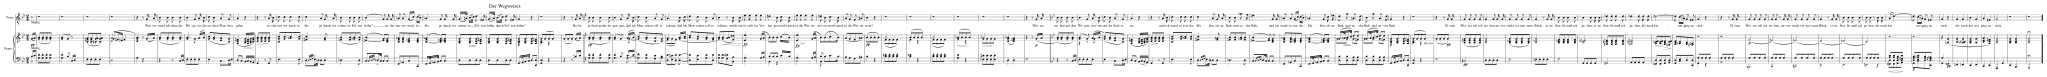

In [36]:
# 1. Extract xml_ids from the 'selection' variable created in the previous cell
# We add the '#' prefix which Verovio expects for plist references
if 'selection' in globals() and not selection.empty:
    selected_xml_ids = ['#' + str(x) for x in selection['xml_id'].dropna().tolist()]
else:
    selected_xml_ids = []

print(f"Passing {len(selected_xml_ids)} selected notes to annotation.")

# 2. Use it in your ANNOTS list
from py_scripts import (
    vrv_set_options, vrv_load_from_url, vrv_process_annotations
)
vrv_set_options(pageWidth=12000, pageHeight=1200, scale=40, breaks="none", removeIds=False, xmlIdSeed=0)
vrv_load_from_url(url)

ANNOTS = [
    # Plist annotation using the selection from the previous cell
    {
        "text": "Filtered Selection", 
        "type": "score", 
        "plist": selected_xml_ids, 
        "xml_id": "selection-annot"
    },
]

# Process all annotations
vrv_process_annotations(
    ANNOTS,
    highlight_color='#5427F5',
    shape_only=True,
    display=True
)

In [29]:
# Refactored pitch distribution using py_scripts.analysis_utils
from py_scripts import display_pitch_distribution

# Configuration for this cell (all lowercase options)
#
# PITCH_X_AXIS controls which pitch representation is used on the X axis:
#   - 'midi': use numeric MIDI values. If 'MIDI' column is missing, it is derived from names.
#   - 'pitch real' (synonyms: 'pitch', 'real'): use real pitch names corresponding to actual semitone values;
#       if only MIDI is present, names are derived from MIDI. Octave is included in the label.
#   - 'pitch enharmonic' (synonyms: 'pitch by name', 'pitch name', 'name', 'pitch_enharmonic', 'pitch-enharmonic'):
#       use written/enharmonic pitch names as notated (prefers 'Pitch Enharmonic' column),
#       preserving the spelled accidentals and octave, even if enharmonically different from real pitch.
PITCH_X_AXIS = 'pitch enharmonic'
#
# ORDER_X_AXIS_BY controls sort order of the X categories:
#   - 'midi' (synonyms: 'pitch real', 'pitch', 'real'):
#       sort by real MIDI number ascending (identical for all synonyms).
#   - 'pitch by octave real' (synonyms: 'pitch by octave', 'pitch octave', 'octave pitch', 'octave real'):
#       sort by REAL octave (computed from MIDI), then by pitch class within each octave.
#       This cares about actual pitch height. Example: B##3 resolves to its real octave (4); Cbb4 resolves to 3.
#   - 'pitch by octave enharmonic' (synonyms: 'octave enharmonic', 'octave name'):
#       sort by WRITTEN octave parsed from the name (ignoring semitone shifts of accidentals),
#       then by letter and accidental. Example: B##3 stays in octave 3; Cbb4 stays in octave 4.
#   - 'pitch by name' (synonyms: 'pitch enharmonic', 'enharmonic', 'enharmonic pitch', 'pitch_enharmonic'):
#       sort by letter (C..B) and accidental rank (bbb < bb < b < natural < # < ## < ###),
#       ignoring octave; ties are stabilized by the full label.
ORDER_X_AXIS_BY = 'midi'

# Plotting backend
PLOTTING_BACKEND = 'bokeh'        # 'plt' | 'bokeh' | 'none'

# Plot sizing for this cell (universal for both backends)
PLOT_SIZE_X = 1200
PLOT_SIZE_Y = 600

# Bokeh hover config
BOKEH_HOVER_VALUES = True

# Choose the DataFrame to visualize
source = selection  # e.g., df1, results[0]['df'], dfs_by_name['00_some_name'] or a selection from df

counts_df = display_pitch_distribution(
    source,
    pitch_axis=PITCH_X_AXIS,
    order_axis_by=ORDER_X_AXIS_BY,
    backend=(PLOTTING_BACKEND.lower() if 'PLOTTING_BACKEND' in globals() else 'plt'),
    plot_width=PLOT_SIZE_X,
    plot_height=PLOT_SIZE_Y,
    show_hover=('BOKEH_HOVER_VALUES' in globals() and BOKEH_HOVER_VALUES),
    show_table=True,
)

,count
Pitch Enharmonic,
G1,1
C2,1
D2,4
Eb2,1
E2,1
F2,1
F#2,2
G2,17
Ab2,2


Loading BokehJS ...

In [ ]:
# Duration distribution: count and visualize as bar plot (plt or bokeh)
# Uses global PLOTTING_BACKEND ('plt' or 'bokeh')

from py_scripts.analysis_utils import display_duration_distribution


# Configuration for this cell
DROP_ZERO_DURATIONS = True          # drop duration == 0
DURATION_ROUND_DECIMALS = 4         # round durations for cleaner categories; set None to disable
BACKEND = (PLOTTING_BACKEND if 'PLOTTING_BACKEND' in globals() else 'plt')

# Choose the DataFrame to visualize
source = selection  # e.g., df1, results[0]['df'], dfs_by_name['00_some_name'] or a selection from df

# Assign to variable to avoid double display (function displays table, return value displays again)
duration_counts = display_duration_distribution(
    source,
    drop_zero=DROP_ZERO_DURATIONS,
    round_decimals=DURATION_ROUND_DECIMALS,
    backend=BACKEND,
    plot_width=1200,
    plot_height=350
)

,count
Duration,
0.25,14
0.50,60
1.00,13
1.50,16
2.00,17
2.50,1
3.00,1


Loading BokehJS ...

In [ ]:
# # Duration distribution: count and visualize as bar plot (plt or bokeh)
# # Uses global PLOTTING_BACKEND ('plt' or 'bokeh')

# import numpy as np
# import pandas as pd

# # Configuration for this cell
# DROP_ZERO_DURATIONS = True          # drop duration == 0
# DURATION_ROUND_DECIMALS = 4         # round durations for cleaner categories; set None to disable

# # Ensure df1 exists
# if 'df1' not in globals():
#     df1 = results[2]['df']

# # Detect duration column
# duration_col = None
# for candidate in ['Duration', 'duration', 'durations', 'Durations']:
#     if candidate in df1.columns:
#         duration_col = candidate
#         break

# if duration_col is None:
#     print("No duration column found. Checked: 'Duration', 'duration', 'durations', 'Durations'.")
# else:
#     ser = df1[duration_col].copy()
#     # Coerce to numeric where possible
#     ser = pd.to_numeric(ser, errors='coerce')
#     ser = ser.dropna()
#     if DROP_ZERO_DURATIONS:
#         ser = ser[ser != 0]
#     if DURATION_ROUND_DECIMALS is not None:
#         ser = ser.round(DURATION_ROUND_DECIMALS)

#     # Aggregate and sort by numeric value (ascending)
#     counts = ser.value_counts().sort_index()

#     # Display table
#     display(counts.rename('count').to_frame())

#     backend = (PLOTTING_BACKEND.lower() if 'PLOTTING_BACKEND' in globals() else 'plt')

#     x_vals = counts.index.astype(str).tolist()
#     y_vals = counts.values.tolist()

#     if backend == 'plt':
#         import matplotlib.pyplot as plt
#         fig, ax = plt.subplots(figsize=(12, 4))
#         ax.bar(x_vals, y_vals, color='seagreen')
#         ax.set_xlabel(duration_col)
#         ax.set_ylabel('Count')
#         ax.set_title('Duration Distribution')
#         plt.xticks(rotation=90)
#         plt.tight_layout()
#         plt.show()

#     elif backend == 'bokeh':
#         from bokeh.plotting import figure, show
#         from bokeh.io import output_notebook
#         from bokeh.models import ColumnDataSource
#         output_notebook()

#         source = ColumnDataSource(dict(x=x_vals, count=y_vals))
#         p = figure(x_range=x_vals, height=350, width=900, title='Duration Distribution', toolbar_location='right')
#         p.vbar(x='x', top='count', width=0.9, source=source, fill_color='#2E8B57')
#         p.xaxis.axis_label = duration_col
#         p.yaxis.axis_label = 'Count'
#         p.xgrid.grid_line_color = None
#         p.y_range.start = 0
#         show(p)

#     else:
#         print(f"Unsupported plotting backend: {backend}. Use 'plt' or 'bokeh'.")



to do: enharmonic, intervall plot, combined plots